In [1]:
import pyvisa as visa
import sys
import time

In [2]:
rm = visa.ResourceManager()
instruments = rm.list_resources()
# instruments
usb = list(filter(lambda x: 'USB' in x, instruments))

keithley = rm.open_resource('USB0::1510::8448::1243106::0::INSTR')

In [3]:
keithley.write("*rst; status:preset; *cls")
v = float(keithley.query('MEAS:VOLT:DC?'))
ref = -1.8e-4
v

-8.77852416e-05

In [4]:
v_dif = v-ref
v_dif

9.221475840000001e-05

In [5]:

def power_supply(v):
    
    psu.write("OUTP CH2,ON")
    psu.write(f"CH2:VOLT {v}")
    time.sleep(0.1)

    actual_volt = psu.query("MEAS:VOLT? CH2")
    print(f"Measured Output -> Voltage: {actual_volt.strip()}")


In [11]:
def sample():
    s = 0
    for x in range(10):
        s += float(keithley.query('MEAS:VOLT:DC?'))
    return s/10


In [7]:
def extra_f(v_before, add_f):
    if len(v_before) == 3:
        for i in range(len(v_before[1:])):
            if v_before[i-1]/v_before[i] < 0.90:
                break
            elif i == 1:
                print("did it")
                return add_f + 1
    return add_f

In [8]:
rm = visa.ResourceManager('@py')
resource_name = 'USB0::62700::5168::SPD3XJEQ6R3774::0::INSTR'
print(f"Connecting to: {resource_name}")
psu = rm.open_resource(resource_name)
psu.timeout = 2000 
idn = psu.query("*IDN?")
print(f"\nSuccessfully connected to: {idn.strip()}")

time.sleep(0.5) 
print("Turning ON Channel 2...")

sec = 1
t = 60
v_dif = sample() - ref
v_before = []
add_f = 1
l = []
lt = []
t_0 = time.time()
while t > 0:
    s = sample()
    v_dif = s - ref
    l.append(s)
    lt.append(time.time()-t_0)
    if len(v_before) == 3:
        v_before.pop(0)
    v_before.append(v_dif)
    if v_dif > 0:
        add_f = extra_f(v_before, add_f)
        adjust = add_f*((v_dif*(10**4)))
        print(v_dif)
        if adjust > 5:
            sys.exit(-1)
        power_supply(adjust)
    else:
        psu.write("OUTP CH2,OFF")
    time.sleep(sec)
    t-=1
print("done")
psu.write("OUTP CH2,OFF")

Connecting to: USB0::62700::5168::SPD3XJEQ6R3774::0::INSTR

Successfully connected to: Siglent Technologies,SPD3303X-E,SPD3XJEQ6R3774,1.01.01.02.07R2,V3.0
Turning ON Channel 2...
-8.77852416e-05
0.00011607149414399999
Measured Output -> Voltage: 0.73
-8.77852416e-05
0.00011814479216000002
Measured Output -> Voltage: 1.17
did it
-8.77852416e-05
0.00010855191592895998
Measured Output -> Voltage: 1.19
-8.77852416e-05
9.571717252799999e-05
Measured Output -> Voltage: 2.18
-8.77852416e-05
8.691737976480002e-05
Measured Output -> Voltage: 1.92
-8.77852416e-05
7.51788771968e-05
Measured Output -> Voltage: 1.74
-8.77852416e-05
6.341913243199999e-05
Measured Output -> Voltage: 1.51
-8.77852416e-05
5.7192062544e-05
Measured Output -> Voltage: 1.27
did it
-8.77852416e-05
5.986929144000003e-05
Measured Output -> Voltage: 1.15
-8.77852416e-05
5.011256316799994e-05
Measured Output -> Voltage: 1.80
-8.77852416e-05
4.183785244800002e-05
Measured Output -> Voltage: 1.51
-8.77852416e-05
3.28731454400000

14

In [9]:
from edes.modules.detection.detection_utils import plot, plot_ax, big_plt_font
import numpy as np
from matplotlib import pyplot as plt
big_plt_font()

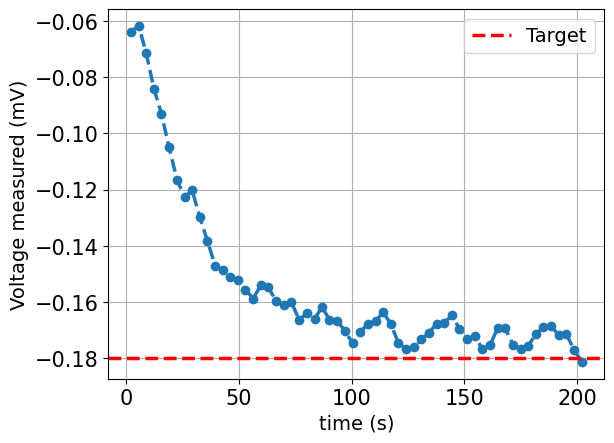

In [10]:
plot(np.array(lt), np.array(l)*1e3, '.--', xlabel='time (s)', ylabel='Voltage measured (mV)')
plt.axhline(ref*1e3, c='r', linestyle='--', label='Target')
plt.legend() 
plt.show()